## Hierarchical Clustering

Hierarchical Clustering is an unsupervised machine learning technique used to group similar data points into clusters.

It builds a tree-like structure called a dendrogram.

### Types of Hierarchical Clustering

1. Agglomerative (Bottom-Up)
- Start with each point as a separate cluster
- Merge closest clusters step by step

2. Divisive (Top-Down)
- Start with one cluster
- Split into smaller clusters

Agglomerative is most commonly used.

#### Advantages

- No need to define number of clusters initially
- Easy to visualize using dendrogram
- Works well for small datasets

#### Disadvantages

- Slow for large datasets
- Sensitive to outliers
- Cannot undo merging steps

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load dataset
dataset = pd.read_csv("Social_Network_Ads.csv")

# Display first 5 rows
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Select only required features (Age & Salary)
X = dataset.iloc[:, [2, 3]].values

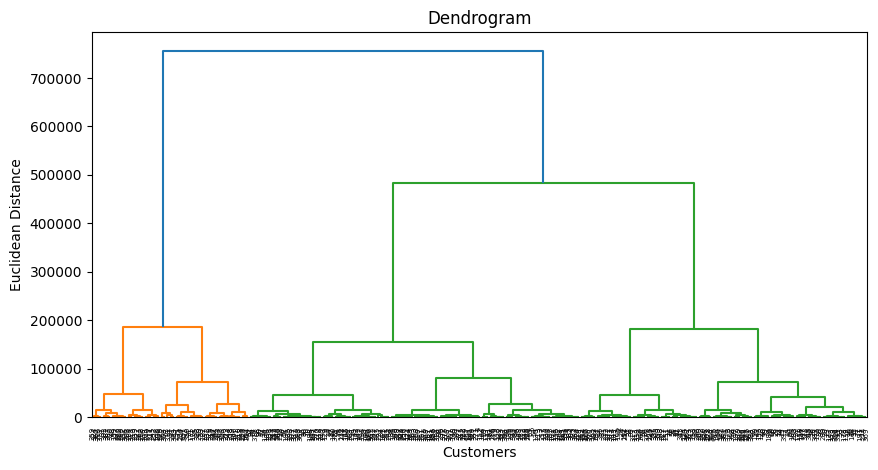

In [4]:
# Import hierarchy for dendrogram
import scipy.cluster.hierarchy as sch

# Plot dendrogram
plt.figure(figsize=(10,5))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [5]:
# Import model
from sklearn.cluster import AgglomerativeClustering

# Create model (choose clusters based on dendrogram)
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Fit model and predict clusters
y_pred = hc.fit_predict(X)

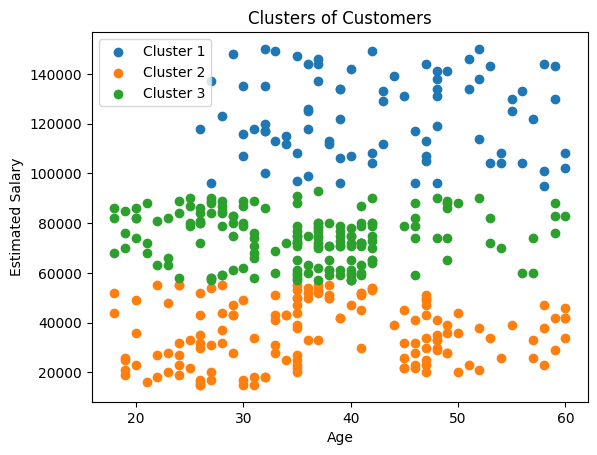

In [6]:
# Plot clusters
plt.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], label='Cluster 1')
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], label='Cluster 2')
plt.scatter(X[y_pred == 2, 0], X[y_pred == 2, 1], label='Cluster 3')

plt.title("Clusters of Customers")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()

plt.show()

| Linkage  | Meaning           | Formula idea    |
| -------- | ----------------- | --------------- |
| Single   | closest point     | min             |
| Complete | farthest point    | max             |
| Average  | average distance  | mean            |
| Ward     | variance minimize | best clustering |
